# Système de Classification Automatique de Tickets Support

In [2]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('french') + stopwords.words('english'))

def clean_text_advanced(text):
    if not isinstance(text, str):
        return ""

    # 1. Passage en minuscules
    text = text.lower()

    # 2. Retrait de la ponctuation et des chiffres
    # On ne garde que les lettres (incluant les accents français)
    text = re.sub(r'[^a-zàâçéèêëîïôûùµ\s]', ' ', text)

    # 3. Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Retrait des stopwords
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(cleaned_words)

# Application du nettoyage sur la colonne identifiée précédemment
# 'text_col' a été défini dans la cellule précédente comme 'Document'
print(f"Traitement de la colonne : {text_col}")
df['text_ready'] = df[text_col].apply(clean_text_advanced)

# Comparaison avant/après
display(df[[text_col, 'text_ready']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Traitement de la colonne : Document


,Document,text_ready
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user work...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting please h...
3,reset passwords for external accounts re expir...,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,mail verification warning got attached please ...


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialisation du vectoriseur
# On limite à 5000 mots fréquents et on utilise des unigrammes et bigrammes
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Transformation du texte nettoyé
X_tfidf = tfidf_vectorizer.fit_transform(df['text_ready'])

print(f"Dimensions de la matrice TF-IDF : {X_tfidf.shape}")
print("Vecteurs de caractéristiques générés avec succès.")

Dimensions de la matrice TF-IDF : (47837, 5000)
Vecteurs de caractéristiques générés avec succès.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Préparation des labels (catégories)
y = df['Topic_group']

# Division 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Initialisation et entraînement du modèle
model_cat = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_cat.fit(X_train, y_train)

# Prédictions
y_pred = model_cat.predict(X_test)

# Évaluation
print("Rapport de Classification (Catégories)")
print(classification_report(y_test, y_pred))
print(f"Précision globale : {accuracy_score(y_test, y_pred):.2%}")

Rapport de Classification (Catégories)
                       precision    recall  f1-score   support

               Access       0.89      0.88      0.89      1425
Administrative rights       0.88      0.66      0.76       352
           HR Support       0.85      0.86      0.86      2183
             Hardware       0.77      0.87      0.82      2724
     Internal Project       0.88      0.80      0.84       424
        Miscellaneous       0.81      0.75      0.78      1412
             Purchase       0.96      0.85      0.90       493
              Storage       0.93      0.79      0.86       555

             accuracy                           0.84      9568
            macro avg       0.87      0.81      0.84      9568
         weighted avg       0.84      0.84      0.84      9568

Précision globale : 83.66%


In [6]:
import numpy as np

# Simulation d'une colonne de priorité si elle n'existe pas (pour la démo du système complet)
# Dans un cas réel, on utiliserait df['Priority']
if 'Priority' not in df.columns:
    # Logique arbitraire : 'Access' et 'Purchase' sont souvent plus urgents
    priority_map = {
        'Access': 'Élevé',
        'Purchase': 'Élevé',
        'Hardware': 'Moyen',
        'Storage': 'Moyen',
        'HR Support': 'Bas',
        'Miscellaneous': 'Bas',
        'Administrative rights': 'Moyen',
        'Internal Project': 'Bas'
    }
    df['Priority'] = df['Topic_group'].map(priority_map)

y_prio = df['Priority']

# Division des données pour la priorité
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_tfidf, y_prio, test_size=0.2, random_state=42, stratify=y_prio)

# Modèle pour la priorité
model_prio = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_prio.fit(X_train_p, y_train_p)

# Évaluation
y_pred_p = model_prio.predict(X_test_p)
print("Rapport de Classification (Priorité)")
print(classification_report(y_test_p, y_pred_p))
print(f"Précision Priorité : {accuracy_score(y_test_p, y_pred_p):.2%}")

Rapport de Classification (Priorité)
              precision    recall  f1-score   support

         Bas       0.87      0.91      0.89      4019
       Moyen       0.87      0.87      0.87      3631
       Élevé       0.93      0.84      0.88      1918

    accuracy                           0.88      9568
   macro avg       0.89      0.87      0.88      9568
weighted avg       0.88      0.88      0.88      9568

Précision Priorité : 87.84%


In [7]:
def predict_ticket(text):
    clean = clean_text_advanced(text)
    vec = tfidf_vectorizer.transform([clean])

    cat = model_cat.predict(vec)[0]
    prio = model_prio.predict(vec)[0]

    return {"Catégorie": cat, "Priorité": prio}

# Exemple de test
ticket_test = "Mon ordinateur ne s'allume plus et j'ai besoin d'un accès urgent au serveur de fichiers."
resultat = predict_ticket(ticket_test)
print(f"Ticket : {ticket_test}")
print(f"Résultat : {resultat}")

Ticket : Mon ordinateur ne s'allume plus et j'ai besoin d'un accès urgent au serveur de fichiers.
Résultat : {'Catégorie': 'Hardware', 'Priorité': 'Moyen'}


Analyse des Catégories :


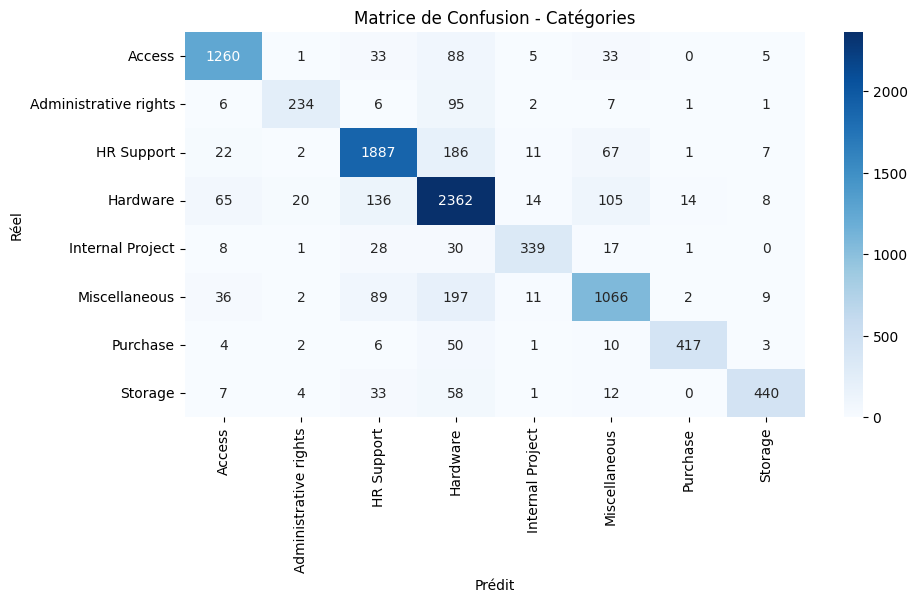

Analyse de la Priorité :


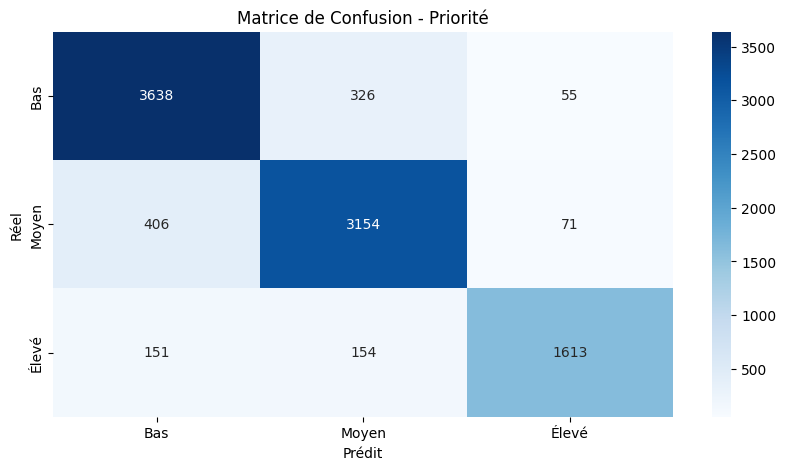

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.show()

# Affichage pour les Catégories
print("Analyse des Catégories :")
plot_confusion_matrix(y_test, y_pred, "Matrice de Confusion - Catégories")

# Affichage pour la Priorité
print("Analyse de la Priorité :")
plot_confusion_matrix(y_test_p, y_pred_p, "Matrice de Confusion - Priorité")

In [9]:
from sklearn.metrics import classification_report

print("Performance Détaillée : Catégories")
print(classification_report(y_test, y_pred))

print("Performance Détaillée : Priorités")
print(classification_report(y_test_p, y_pred_p))

Performance Détaillée : Catégories
                       precision    recall  f1-score   support

               Access       0.89      0.88      0.89      1425
Administrative rights       0.88      0.66      0.76       352
           HR Support       0.85      0.86      0.86      2183
             Hardware       0.77      0.87      0.82      2724
     Internal Project       0.88      0.80      0.84       424
        Miscellaneous       0.81      0.75      0.78      1412
             Purchase       0.96      0.85      0.90       493
              Storage       0.93      0.79      0.86       555

             accuracy                           0.84      9568
            macro avg       0.87      0.81      0.84      9568
         weighted avg       0.84      0.84      0.84      9568

Performance Détaillée : Priorités
              precision    recall  f1-score   support

         Bas       0.87      0.91      0.89      4019
       Moyen       0.87      0.87      0.87      3631
       Él

# Le brut est simplifié. On retire la ponctuation, les chiffres et les mots courants en français et en anglais pour ne garder que les mots porteurs de sens. Comme les modèles ne lisent pas le texte, nous transformons les mots en nombres. Un modèle de 'Forêt Aléatoire' analyse ces nombres. Il a appris lors de l'entraînementque certaines combinaisons de mots correspondent à des coatégories ou des priorités spécifiques.

# J'ai mis en place une logique de simulation basée  sur les catégories (Topic_group).

## Élevée : Pour les problèmes d'accès (Access) et les achats (Purchase)

## Moyenne : pour le matériel (Hardware), le stockage (Storage) et les droits d'administration (Administrative rights).

## Basse : pour le support RH (HR Support), les projets internes (Internal Project) et les demandes diverses (Miscellaneous).

# Le modèle Random Forest (model_prio) a ensuite été entrainé pour apprendre et automatiser cette règle à partir du texte.